# Indigo AI Personalization Project

## Step 4 Analytics Notebook

This notebook supports the analytics module for evaluating whether Indigo should invest in an AI-driven lifestyle personalization engine.

### Scope of this section
This notebook begins with simulated customer-level data for 10,000 Plum Rewards members. The simulation focuses on two customer segments:

- **Book-only customers**
- **Multi-category customers**

The simulated dataset will be used in later sections for:
- CLV estimation
- scenario analysis
- sensitivity testing

## 1. Project Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Reproducibility
np.random.seed(42)

## 2. Assumptions and Segmet Definations

We simulate 10,000 customers across two segments:

- **Book-only customers**
- **Multi-category customers**

### Segment-level assumptions

| Segment | Purchase Frequency (orders/year) | Average Order Value ($) | Contribution Margin | Retention Probability |
|--------|-----------------------------------|--------------------------|---------------------|----------------------|
| Book-only | 3 | 25 | 30% | 60% |
| Multi-category | 5 | 45 | 35% | 80% |

### Distribution choices

- **Purchase frequency** is modeled using a **zero-truncated Poisson distribution**, so every simulated customer has at least one annual order.
- **Average order value (AOV)** is modeled using a **log-normal distribution** calibrated so the arithmetic mean matches the target segment AOV.
- **Retention** is modeled as a **Bernoulli variable**, representing whether a customer remains active in the next period.
- **Margin** is treated as fixed within segment for simplicity.

## 3. Simulating 10,000 Customers

In [3]:
# -----------------------------
# Simulation parameters
# -----------------------------
N = 10000

# Segment mix assumption
book_share = 0.70
multi_share = 0.30

# Book-only segment parameters
book_freq_lambda = 3
book_aov_mean = 25
book_aov_sigma = 0.30
book_margin = 0.30
book_retention_prob = 0.60

# Multi-category segment parameters
multi_freq_lambda = 5
multi_aov_mean = 45
multi_aov_sigma = 0.40
multi_margin = 0.35
multi_retention_prob = 0.80

In [4]:
# Generate segment labels based on the specified mix
segments = np.random.choice(
    ["book_only", "multi_category"],
    size=N,
    p=[book_share, multi_share]
)

df = pd.DataFrame({
    "customer_id": np.arange(1, N + 1),
    "segment": segments
})

df.head()

,customer_id,segment
0,1,book_only
1,2,multi_category
2,3,multi_category
3,4,book_only
4,5,book_only


In [5]:
# ------------------------------
# Simulate customer variables based on segment
# ------------------------------

def zero_truncated_poisson(lam, size):
    samples = np.random.poisson(lam=lam, size=size)
    while (samples == 0).any():
        zero_mask = samples == 0
        samples[zero_mask] = np.random.poisson(lam=lam, size=zero_mask.sum())
    return samples

def lognormal_mu_from_mean(target_mean, sigma):
    return np.log(target_mean) - 0.5 * sigma**2

# Initialize columns
df["purchase_frequency"] = np.nan
df["AOV"] = np.nan
df["margin"] = np.nan
df["retention"] = np.nan

# Masks
mask_book = df["segment"] == "book_only"
mask_multi = df["segment"] == "multi_category"

n_book = mask_book.sum()
n_multi = mask_multi.sum()

book_aov_mu = lognormal_mu_from_mean(book_aov_mean, book_aov_sigma)
multi_aov_mu = lognormal_mu_from_mean(multi_aov_mean, multi_aov_sigma)

# -----------------------------
# Book-only customers
# -----------------------------
df.loc[mask_book, "purchase_frequency"] = zero_truncated_poisson(
    lam=book_freq_lambda,
    size=n_book
)

df.loc[mask_book, "AOV"] = np.random.lognormal(
    mean=book_aov_mu,
    sigma=book_aov_sigma,
    size=n_book
)

df.loc[mask_book, "margin"] = book_margin

df.loc[mask_book, "retention"] = np.random.binomial(
    n=1,
    p=book_retention_prob,
    size=n_book
)

# -----------------------------
# Multi-category customers
# -----------------------------
df.loc[mask_multi, "purchase_frequency"] = zero_truncated_poisson(
    lam=multi_freq_lambda,
    size=n_multi
)

df.loc[mask_multi, "AOV"] = np.random.lognormal(
    mean=multi_aov_mu,
    sigma=multi_aov_sigma,
    size=n_multi
)

df.loc[mask_multi, "margin"] = multi_margin

df.loc[mask_multi, "retention"] = np.random.binomial(
    n=1,
    p=multi_retention_prob,
    size=n_multi
)

df.head()

,customer_id,segment,purchase_frequency,AOV,margin,retention
0,1,book_only,2.0,24.736906,0.30,0.0
1,2,multi_category,7.0,38.965100,0.35,0.0
2,3,multi_category,5.0,45.441286,0.35,1.0
3,4,book_only,3.0,31.115186,0.30,1.0
4,5,book_only,7.0,22.136022,0.30,0.0


In [6]:
# ---------------------
# Data cleaning / clipping
# ---------------------

# Apply light caps to avoid unrealistic outliers
df["purchase_frequency"] = df["purchase_frequency"].clip(upper=15)
df["AOV"] = df["AOV"].clip(lower=5, upper=200)

# Round for readability
df["purchase_frequency"] = df["purchase_frequency"].astype(int)
df["AOV"] = df["AOV"].round(2)
df["margin"] = df["margin"].round(2)
df["retention"] = df["retention"].astype(int)

df.head()

,customer_id,segment,purchase_frequency,AOV,margin,retention
0,1,book_only,2,24.74,0.30,0
1,2,multi_category,7,38.97,0.35,0
2,3,multi_category,5,45.44,0.35,1
3,4,book_only,3,31.12,0.30,1
4,5,book_only,7,22.14,0.30,0


In [7]:
assert df["customer_id"].is_unique
assert not df.isnull().any().any()
assert df["retention"].isin([0, 1]).all()

print("Dataset shape:", df.shape)
print("\nSegment counts:")
print(df["segment"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

print("\nSegment-level means:")
print(
    df.groupby("segment")[["purchase_frequency", "AOV", "retention"]]
    .mean()
    .round(2)
)

Dataset shape: (10000, 6)

Segment counts:
segment
book_only         7113
multi_category    2887
Name: count, dtype: int64

Missing values:
customer_id           0
segment               0
purchase_frequency    0
AOV                   0
margin                0
retention             0
dtype: int64

Segment-level means:
                purchase_frequency    AOV  retention
segment                                             
book_only                     3.17  24.82       0.59
multi_category                5.07  45.16       0.81


## 4. Summary Statistics

In [8]:
summary_stats = df.groupby("segment").agg(
    customers=("customer_id", "count"),
    avg_purchase_frequency=("purchase_frequency", "mean"),
    avg_AOV=("AOV", "mean"),
    avg_margin=("margin", "mean"),
    avg_retention=("retention", "mean")
).reset_index()

summary_stats["avg_purchase_frequency"] = summary_stats["avg_purchase_frequency"].round(2)
summary_stats["avg_AOV"] = summary_stats["avg_AOV"].round(2)
summary_stats["avg_margin"] = summary_stats["avg_margin"].round(2)
summary_stats["avg_retention"] = summary_stats["avg_retention"].round(2)

summary_stats

,segment,customers,avg_purchase_frequency,avg_AOV,avg_margin,avg_retention
0,book_only,7113,3.17,24.82,0.30,0.59
1,multi_category,2887,5.07,45.16,0.35,0.81


In [9]:
df["annual_profit"] = (
    df["purchase_frequency"] * df["AOV"] * df["margin"]
).round(2)

df.head()

,customer_id,segment,purchase_frequency,AOV,margin,retention,annual_profit
0,1,book_only,2,24.74,0.30,0,14.84
1,2,multi_category,7,38.97,0.35,0,95.48
2,3,multi_category,5,45.44,0.35,1,79.52
3,4,book_only,3,31.12,0.30,1,28.01
4,5,book_only,7,22.14,0.30,0,46.49


In [10]:
# Summary including annual profit

profit_summary = df.groupby("segment").agg(
    customers=("customer_id", "count"),
    avg_purchase_frequency=("purchase_frequency", "mean"),
    avg_AOV=("AOV", "mean"),
    avg_margin=("margin", "mean"),
    avg_retention=("retention", "mean"),
    avg_annual_profit=("annual_profit", "mean")
).reset_index()

profit_summary = profit_summary.round({
    "avg_purchase_frequency": 2,
    "avg_AOV": 2,
    "avg_margin": 2,
    "avg_retention": 2,
    "avg_annual_profit": 2
})

profit_summary

,segment,customers,avg_purchase_frequency,avg_AOV,avg_margin,avg_retention,avg_annual_profit
0,book_only,7113,3.17,24.82,0.30,0.59,23.69
1,multi_category,2887,5.07,45.16,0.35,0.81,80.33


## 5. Export Simulated Dataset

In [11]:
output_path = "indigo_simulated_customers.csv"
df.to_csv(output_path, index=False)
print(f"Simulated dataset exported to: {output_path}")

Simulated dataset exported to: indigo_simulated_customers.csv


## 6. CLV Modeling

We use the following retention-based discounted cash flow CLV model:

$$CLV_i = \sum_{t=1}^{T} \frac{(AOV_i \cdot f_i \cdot m_i) \cdot r_i^t}{(1+d)^t}$$

Where:
- $AOV_i$ = average order value for customer $i$
- $f_i$ = annual purchase frequency for customer $i$
- $m_i$ = contribution margin for customer $i$
- $r_i$ = retention probability used for projection
- $d$ = annual discount rate
- $T$ = forecast horizon in years

In this notebook, $r_i$ is the **segment-level retention rate** assigned to each customer, not the realized binary `retention` draw. This keeps the model aligned with the formula as an expected-value CLV approach rather than a one-period realized outcome.

If Indigo later wants a probabilistic CLV model such as BG/NBD, the simulation would need richer transaction-level history such as recency, tenure, and purchase timing.

In [18]:
sns.set_theme(style="whitegrid", palette="deep")
# ---------------------
# CLV model parameters
# ---------------------
discount_rate = 0.10
forecast_horizon = 5

segment_retention_map = {
    "book_only": book_retention_prob,
    "multi_category": multi_retention_prob
}

df["retention_rate"] = df["segment"].map(segment_retention_map).astype(float)
df["annual_profit"] = (
    df["AOV"] * df["purchase_frequency"] * df["margin"]
).round(2)

def calculate_clv(annual_profit, retention_rate, discount_rate, forecast_horizon):
    periods = np.arange(1, forecast_horizon + 1)
    discounted_terms = [
        annual_profit * (retention_rate ** t) / ((1 + discount_rate) ** t)
        for t in periods
    ]
    return np.sum(discounted_terms, axis=0)

df["clv"] = calculate_clv(
    annual_profit=df["annual_profit"].values,
    retention_rate=df["retention_rate"].values,
    discount_rate=discount_rate,
    forecast_horizon=forecast_horizon
).round(2)

clv_summary = df.groupby("segment").agg(
    customers=("customer_id", "count"),
    avg_AOV=("AOV", "mean"),
    avg_purchase_frequency=("purchase_frequency", "mean"),
    avg_margin=("margin", "mean"),
    retention_rate=("retention_rate", "mean"),
    avg_annual_profit=("annual_profit", "mean"),
    avg_clv=("clv", "mean"),
    total_clv=("clv", "sum")
).round(2).reset_index()

portfolio_summary = pd.DataFrame({
    "metric": ["customers", "average_clv", "total_clv"],
    "value": [len(df), round(df["clv"].mean(), 2), round(df["clv"].sum(), 2)]
})
segment_label_map = {
    "book_only": "Book-only",
    "multi_category": "Multi-category"
}
df["segment_label"] = df["segment"].map(segment_label_map)
clv_summary["segment_label"] = clv_summary["segment"].map(segment_label_map)
clv_summary["clv_share_pct"] = (clv_summary["total_clv"] / clv_summary["total_clv"].sum() * 100).round(2)

assert np.allclose(
    df["annual_profit"],
    (df["AOV"] * df["purchase_frequency"] * df["margin"]).round(2)
)
assert clv_summary.loc[
    clv_summary["segment"] == "multi_category", "avg_clv"
].iloc[0] > clv_summary.loc[
    clv_summary["segment"] == "book_only", "avg_clv"
].iloc[0]

print("Base-case CLV assumptions")
print({"discount_rate": discount_rate, "forecast_horizon": forecast_horizon})
print("\nPortfolio summary")
display(portfolio_summary)
print("\nSegment-level CLV summary")
display(clv_summary.rename(columns={
    "segment_label": "Segment",
    "customers": "Customers",
    "avg_AOV": "Average AOV",
    "avg_purchase_frequency": "Average Purchase Frequency",
    "avg_margin": "Average Margin",
    "retention_rate": "Retention Rate",
    "avg_annual_profit": "Average Annual Profit",
    "avg_clv": "Average CLV",
    "total_clv": "Total CLV",
    "clv_share_pct": "Share of Total CLV (%)"
})[["Segment", "Customers", "Average AOV", "Average Purchase Frequency", "Average Margin", "Retention Rate", "Average Annual Profit", "Average CLV", "Total CLV", "Share of Total CLV (%)"]])
print("\nCustomer-level CLV sample")
display(df[["customer_id", "segment_label", "annual_profit", "retention_rate", "clv"]].head().rename(columns={
    "customer_id": "Customer ID",
    "segment_label": "Segment",
    "annual_profit": "Annual Profit",
    "retention_rate": "Retention Rate",
    "clv": "CLV"
}))


Base-case CLV assumptions
{'discount_rate': 0.1, 'forecast_horizon': 5}

Portfolio summary


,metric,value
0,customers,10000.00
1,average_clv,68.50
2,total_clv,685034.86



Segment-level CLV summary


,Segment,Customers,Average AOV,Average Purchase Frequency,Average Margin,Retention Rate,Average Annual Profit,Average CLV,Total CLV,Share of Total CLV (%)
0,Book-only,7113,24.82,3.17,0.30,0.6,23.69,27.05,192414.72,28.09
1,Multi-category,2887,45.16,5.07,0.35,0.8,80.33,170.63,492620.14,71.91



Customer-level CLV sample


,Customer ID,Segment,Annual Profit,Retention Rate,CLV
0,1,Book-only,14.84,0.6,16.95
1,2,Multi-category,95.48,0.8,202.81
2,3,Multi-category,79.52,0.8,168.91
3,4,Book-only,28.01,0.6,31.99
4,5,Book-only,46.49,0.6,53.09


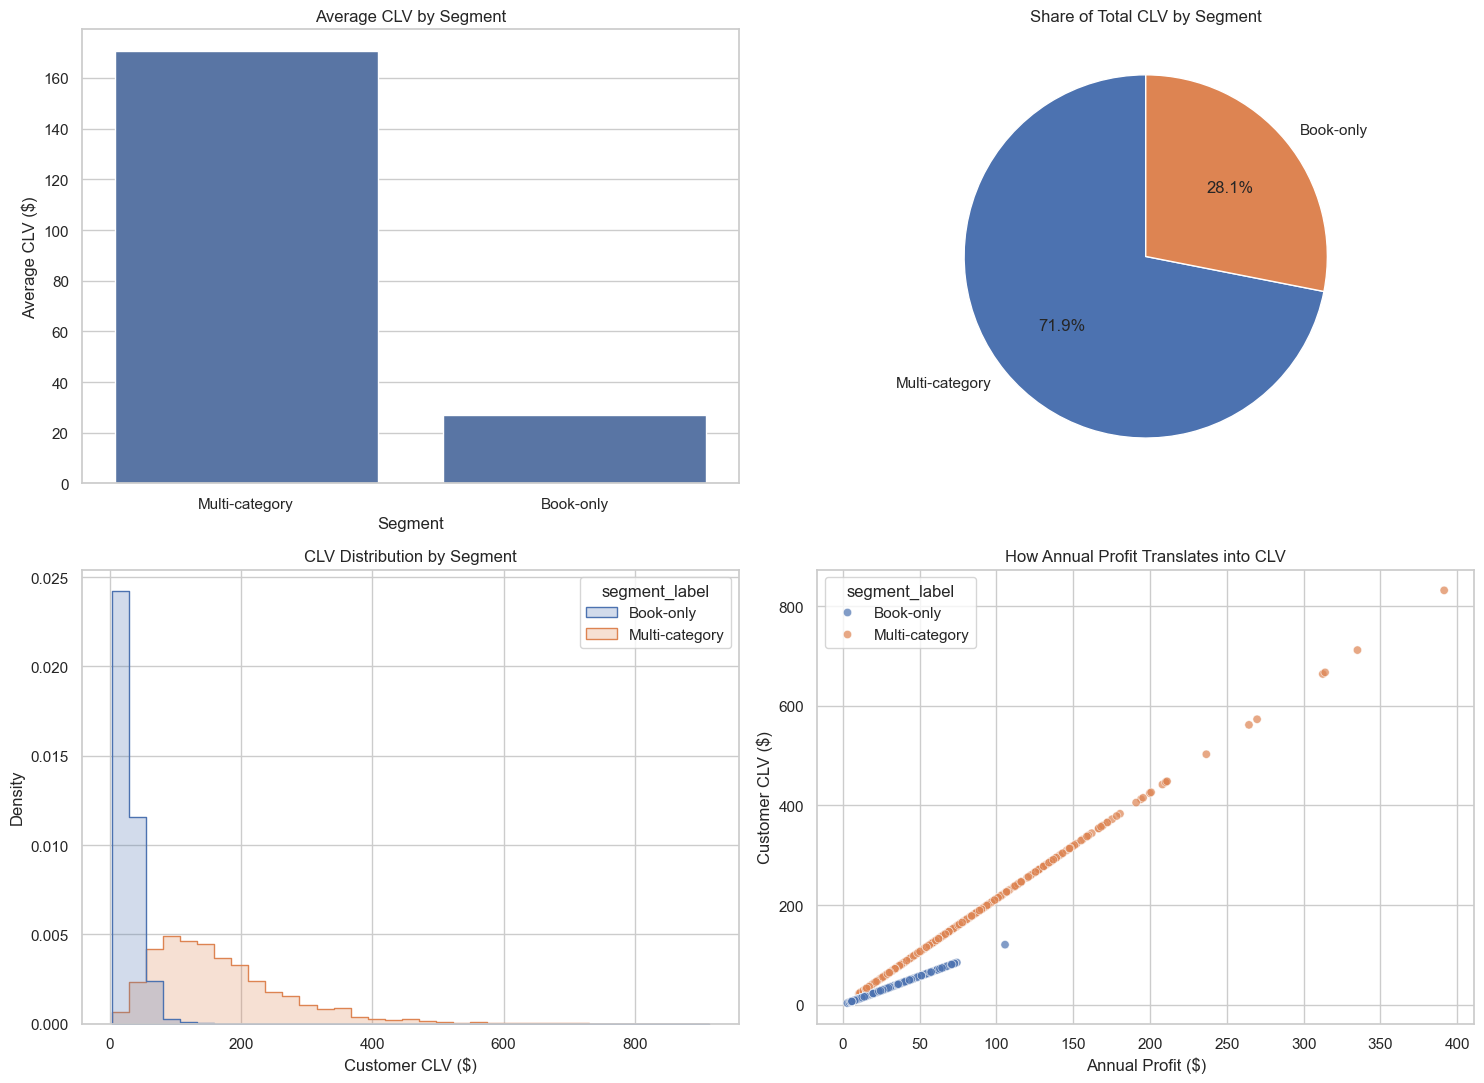

Top 10 customers by predicted CLV


,Customer ID,Segment,Purchase Frequency,AOV,Retention Rate,Annual Profit,CLV
796,797,Multi-category,9,136.39,0.8,429.63,912.58
7027,7028,Multi-category,8,148.40,0.8,415.52,882.60
2913,2914,Multi-category,7,159.78,0.8,391.46,831.50
2722,2723,Multi-category,7,154.89,0.8,379.48,806.05
4469,4470,Multi-category,11,91.77,0.8,353.31,750.46
9886,9887,Multi-category,6,163.78,0.8,343.94,730.56
1355,1356,Multi-category,11,87.02,0.8,335.03,711.64
7626,7627,Multi-category,10,93.91,0.8,328.68,698.15
8116,8117,Multi-category,11,84.41,0.8,324.98,690.29
6058,6059,Multi-category,6,153.71,0.8,322.79,685.64


In [19]:
# model visualization
segment_order = clv_summary.sort_values("avg_clv", ascending=False)["segment_label"]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

sns.barplot(data=clv_summary, x="segment_label", y="avg_clv", order=segment_order, ax=axes[0, 0])
axes[0, 0].set_title("Average CLV by Segment")
axes[0, 0].set_xlabel("Segment")
axes[0, 0].set_ylabel("Average CLV ($)")

axes[0, 1].pie(
    clv_summary.sort_values("avg_clv", ascending=False)["clv_share_pct"],
    labels=clv_summary.sort_values("avg_clv", ascending=False)["segment_label"],
    autopct="%1.1f%%",
    startangle=90
)
axes[0, 1].set_title("Share of Total CLV by Segment")

sns.histplot(data=df, x="clv", hue="segment_label", bins=35, element="step", stat="density", common_norm=False, ax=axes[1, 0])
axes[1, 0].set_title("CLV Distribution by Segment")
axes[1, 0].set_xlabel("Customer CLV ($)")
axes[1, 0].set_ylabel("Density")

sampled_df = df.sample(min(len(df), 1200), random_state=42)
sns.scatterplot(
    data=sampled_df,
    x="annual_profit",
    y="clv",
    hue="segment_label",
    alpha=0.7,
    ax=axes[1, 1]
)
axes[1, 1].set_title("How Annual Profit Translates into CLV")
axes[1, 1].set_xlabel("Annual Profit ($)")
axes[1, 1].set_ylabel("Customer CLV ($)")

plt.tight_layout()
plt.show()

top_clv_customers = df.nlargest(10, "clv")[
    ["customer_id", "segment_label", "purchase_frequency", "AOV", "retention_rate", "annual_profit", "clv"]
].rename(columns={
    "customer_id": "Customer ID",
    "segment_label": "Segment",
    "purchase_frequency": "Purchase Frequency",
    "AOV": "AOV",
    "retention_rate": "Retention Rate",
    "annual_profit": "Annual Profit",
    "clv": "CLV"
})
print("Top 10 customers by predicted CLV")
display(top_clv_customers)


## 7. Scenario Analysis

Scenario analysis evaluates how AI personalization could improve CLV by changing one or more customer-level drivers in the formula. We compare the base case with targeted uplifts to frequency, AOV, margin, and retention.

In [20]:
scenario_settings = {
    "Base Case": {"aov_mult": 1.00, "freq_mult": 1.00, "margin_mult": 1.00, "retention_add": 0.00},
    "AI Uplift: Retention": {"aov_mult": 1.00, "freq_mult": 1.00, "margin_mult": 1.00, "retention_add": 0.05},
    "AI Uplift: AOV": {"aov_mult": 1.08, "freq_mult": 1.00, "margin_mult": 1.00, "retention_add": 0.00},
    "AI Uplift: Frequency": {"aov_mult": 1.00, "freq_mult": 1.10, "margin_mult": 1.00, "retention_add": 0.00},
    "AI Uplift: Combined": {"aov_mult": 1.08, "freq_mult": 1.10, "margin_mult": 1.02, "retention_add": 0.05}
}

scenario_rows = []
scenario_segment_rows = []
base_total_clv = df["clv"].sum()

for scenario_name, params in scenario_settings.items():
    scenario_df = df.copy()
    scenario_df["scenario_AOV"] = scenario_df["AOV"] * params["aov_mult"]
    scenario_df["scenario_frequency"] = scenario_df["purchase_frequency"] * params["freq_mult"]
    scenario_df["scenario_margin"] = (scenario_df["margin"] * params["margin_mult"]).clip(upper=0.95)
    scenario_df["scenario_retention_rate"] = (scenario_df["retention_rate"] + params["retention_add"]).clip(upper=0.99)
    scenario_df["scenario_annual_profit"] = (
        scenario_df["scenario_AOV"] * scenario_df["scenario_frequency"] * scenario_df["scenario_margin"]
    )
    scenario_df["scenario_clv"] = calculate_clv(
        annual_profit=scenario_df["scenario_annual_profit"].values,
        retention_rate=scenario_df["scenario_retention_rate"].values,
        discount_rate=discount_rate,
        forecast_horizon=forecast_horizon
    )

    scenario_rows.append({
        "scenario": scenario_name,
        "avg_clv": round(scenario_df["scenario_clv"].mean(), 2),
        "total_clv": round(scenario_df["scenario_clv"].sum(), 2),
        "lift_vs_base_pct": round((scenario_df["scenario_clv"].sum() / base_total_clv - 1) * 100, 2)
    })

    segment_scenario = scenario_df.groupby("segment").agg(
        avg_clv=("scenario_clv", "mean"),
        total_clv=("scenario_clv", "sum")
    ).reset_index()
    segment_scenario["segment_label"] = segment_scenario["segment"].map(segment_label_map)
    segment_scenario["scenario"] = scenario_name
    scenario_segment_rows.append(segment_scenario)

scenario_summary = pd.DataFrame(scenario_rows).sort_values("total_clv", ascending=False)
scenario_segment_summary = pd.concat(scenario_segment_rows, ignore_index=True)

display(scenario_summary.rename(columns={
    "scenario": "Scenario",
    "avg_clv": "Average CLV",
    "total_clv": "Total CLV",
    "lift_vs_base_pct": "Lift vs. Base Case (%)"
}))


,Scenario,Average CLV,Total CLV,Lift vs. Base Case (%)
4,AI Uplift: Combined,96.59,965909.78,41.00
1,AI Uplift: Retention,79.71,797113.11,16.36
3,AI Uplift: Frequency,75.35,753540.63,10.00
2,AI Uplift: AOV,73.98,739839.89,8.00
0,Base Case,68.50,685036.93,0.00


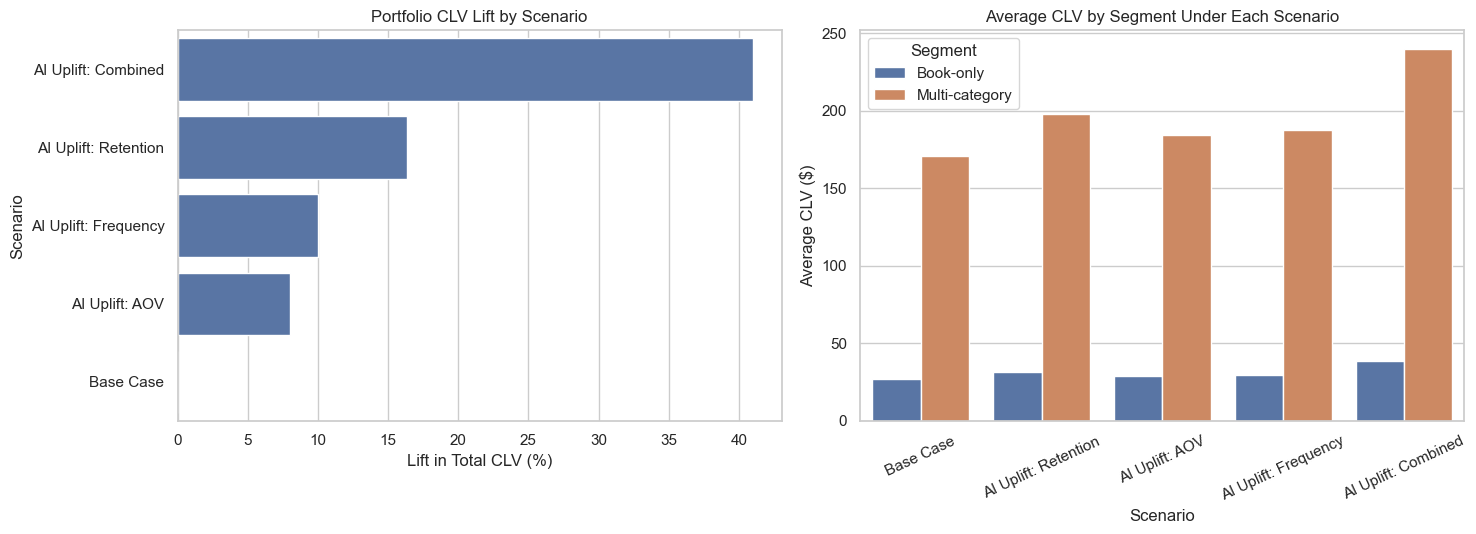

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.barplot(data=scenario_summary, x="lift_vs_base_pct", y="scenario", ax=axes[0])
axes[0].set_title("Portfolio CLV Lift by Scenario")
axes[0].set_xlabel("Lift in Total CLV (%)")
axes[0].set_ylabel("Scenario")

sns.barplot(
    data=scenario_segment_summary,
    x="scenario",
    y="avg_clv",
    hue="segment_label",
    ax=axes[1]
)
axes[1].set_title("Average CLV by Segment Under Each Scenario")
axes[1].set_xlabel("Scenario")
axes[1].set_ylabel("Average CLV ($)")
axes[1].legend(title="Segment")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


## 8. Sensitivity Analysis

Sensitivity analysis tests which assumptions matter most for CLV. We vary one parameter at a time while holding the others fixed at the base case.

In [22]:
def total_clv_with_inputs(annual_profit, retention_rate, discount_rate, forecast_horizon):
    return calculate_clv(
        annual_profit=np.asarray(annual_profit),
        retention_rate=np.asarray(retention_rate),
        discount_rate=discount_rate,
        forecast_horizon=forecast_horizon
    ).sum()

base_total_clv = round(df["clv"].sum(), 2)
sensitivity_rows = []

for discount in [0.08, 0.10, 0.12]:
    total = total_clv_with_inputs(df["annual_profit"], df["retention_rate"], discount, forecast_horizon)
    sensitivity_rows.append({"parameter": "Discount Rate", "value": discount, "total_clv": round(total, 2)})

for horizon in [3, 5, 7]:
    total = total_clv_with_inputs(df["annual_profit"], df["retention_rate"], discount_rate, horizon)
    sensitivity_rows.append({"parameter": "Forecast Horizon", "value": horizon, "total_clv": round(total, 2)})

for retention_shift in [-0.05, 0.00, 0.05]:
    shifted_retention = (df["retention_rate"] + retention_shift).clip(lower=0.01, upper=0.99)
    total = total_clv_with_inputs(df["annual_profit"], shifted_retention, discount_rate, forecast_horizon)
    sensitivity_rows.append({"parameter": "Retention Change", "value": retention_shift, "total_clv": round(total, 2)})

for aov_mult in [0.95, 1.00, 1.05]:
    total = total_clv_with_inputs(df["annual_profit"] * aov_mult, df["retention_rate"], discount_rate, forecast_horizon)
    sensitivity_rows.append({"parameter": "AOV Change", "value": aov_mult, "total_clv": round(total, 2)})

for freq_mult in [0.95, 1.00, 1.05]:
    total = total_clv_with_inputs(df["annual_profit"] * freq_mult, df["retention_rate"], discount_rate, forecast_horizon)
    sensitivity_rows.append({"parameter": "Purchase Frequency Change", "value": freq_mult, "total_clv": round(total, 2)})

for margin_mult in [0.95, 1.00, 1.05]:
    total = total_clv_with_inputs(df["annual_profit"] * margin_mult, df["retention_rate"], discount_rate, forecast_horizon)
    sensitivity_rows.append({"parameter": "Margin Change", "value": margin_mult, "total_clv": round(total, 2)})

sensitivity_summary = pd.DataFrame(sensitivity_rows)
sensitivity_summary["lift_vs_base_pct"] = ((sensitivity_summary["total_clv"] / base_total_clv) - 1).round(4) * 100
sensitivity_summary = sensitivity_summary.sort_values(["parameter", "value"]).reset_index(drop=True)

assert total_clv_with_inputs(df["annual_profit"], df["retention_rate"], 0.08, forecast_horizon) > total_clv_with_inputs(df["annual_profit"], df["retention_rate"], 0.12, forecast_horizon)
assert total_clv_with_inputs(df["annual_profit"], (df["retention_rate"] + 0.05).clip(upper=0.99), discount_rate, forecast_horizon) > total_clv_with_inputs(df["annual_profit"], df["retention_rate"], discount_rate, forecast_horizon)

display(sensitivity_summary.rename(columns={
    "parameter": "Assumption",
    "value": "Assumption Value",
    "total_clv": "Total CLV",
    "lift_vs_base_pct": "Lift vs. Base Case (%)"
}))


,Assumption,Assumption Value,Total CLV,Lift vs. Base Case (%)
0,AOV Change,0.95,650783.01,-5.00
1,AOV Change,1.00,685034.75,-0.00
2,AOV Change,1.05,719286.49,5.00
3,Discount Rate,0.08,714307.76,4.27
4,Discount Rate,0.10,685034.75,-0.00
5,Discount Rate,0.12,657817.42,-3.97
6,Forecast Horizon,3.00,549916.81,-19.72
7,Forecast Horizon,5.00,685034.75,-0.00
8,Forecast Horizon,7.00,751168.60,9.65
9,Margin Change,0.95,650783.01,-5.00


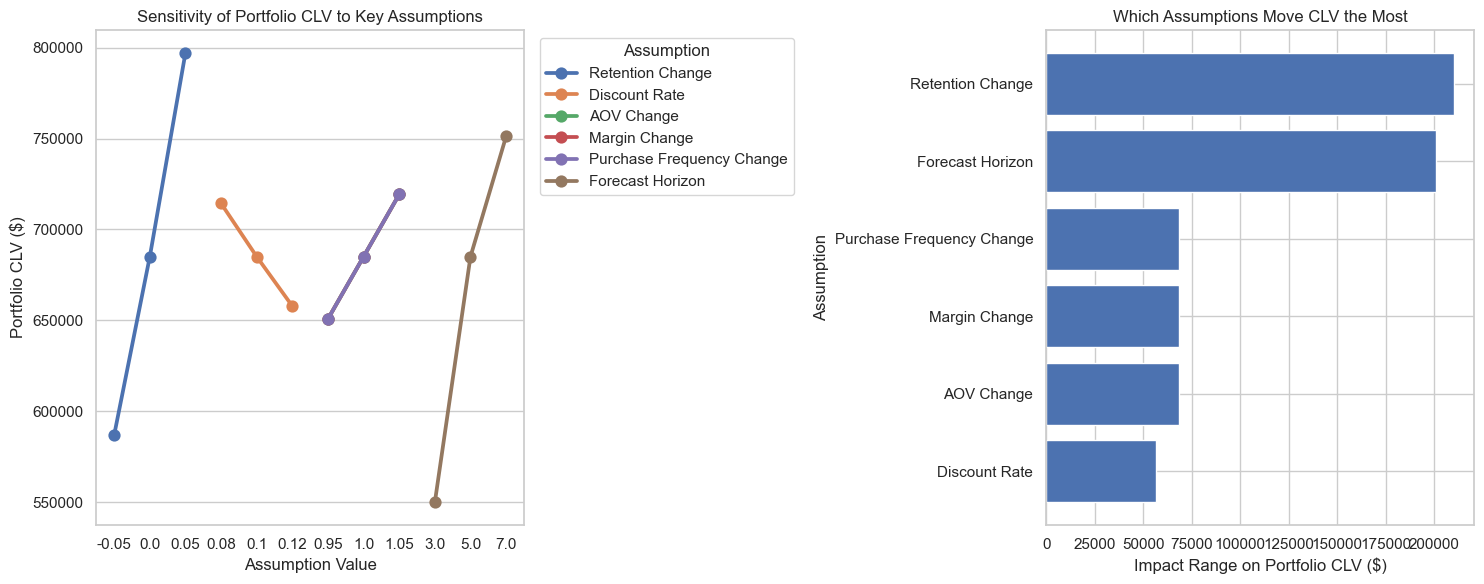

In [23]:
parameter_impact = sensitivity_summary.groupby("parameter").agg(
    min_total_clv=("total_clv", "min"),
    max_total_clv=("total_clv", "max")
).reset_index()
parameter_impact["impact_range"] = parameter_impact["max_total_clv"] - parameter_impact["min_total_clv"]
parameter_impact = parameter_impact.sort_values("impact_range", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.pointplot(data=sensitivity_summary, x="value", y="total_clv", hue="parameter", ax=axes[0])
axes[0].set_title("Sensitivity of Portfolio CLV to Key Assumptions")
axes[0].set_xlabel("Assumption Value")
axes[0].set_ylabel("Portfolio CLV ($)")
axes[0].legend(title="Assumption", bbox_to_anchor=(1.02, 1), loc="upper left")

axes[1].barh(parameter_impact["parameter"], parameter_impact["impact_range"])
axes[1].set_title("Which Assumptions Move CLV the Most")
axes[1].set_xlabel("Impact Range on Portfolio CLV ($)")
axes[1].set_ylabel("Assumption")

plt.tight_layout()
plt.show()
